In [1]:
from _utils import *
from _regex_functions import *

In [4]:
raw_gpt_bl = pd.read_excel(GPT_DIR / "gpt_baseline_run1.xlsx").rename(columns={"hash":"file_hash","mechanisms":"gpt_pred_subtype"})
raw_gpt_aug = pd.read_excel(GPT_DIR / "gpt_with_heuristics.xlsx").rename(columns={"hash":"file_hash","mechanisms":"gpt_pred_subtype"})
label_df = pd.read_csv(PIPELINE_DATA_DIR / "split_df2_with_labels.csv")
ANNOTATED_SAMPLES = label_df.query("set == 'test'")["file_hash"].tolist()

In [23]:
def to_set(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return set()
    if isinstance(x, set):
        return x
    if isinstance(x, list):
        return set(i.strip() for i in x)
    if isinstance(x, str):
        return {i.strip() for i in x.split(",") if i.strip()}
    return set()


In [5]:
raw_gpt_bl

,file_hash,gpt_pred_subtype,notes
0,cf53b079807fc6711d9563031aae227dd1a73cf5add973...,I K (Ca-activated),Conductance gkca is instantaneous Hill(ci) wit...
1,04c32cd101754ad7f2eaf278919c6ce85b8a7d67149fca...,R Glutamate (NMDA),Implements NMDA as a SUFFIX density mechanism ...
2,2d3c5c121271cfad6d2e35db7d2c418de64f97e57c20a0...,I Ca (T-type LT),Implements thalamic relay neuron T-current (Hu...
3,e2f71ea16f8378b3cf0670f9bd5e457634824ab9ee8a7c...,I K (Delayed Rectifier),Implements n and complementary c with CONSERVE...
4,04860f65d331d381e779e488566f95ab0e1fa4960b50a7...,I Na (Transient),Uses KINETIC scheme with ma/mb and ha/hb two-s...
...,...,...,...
5128,6eb9a4841886c662fe30872c3950edaa2dcd456018e529...,I Ca (HVA),Uses ohmic driving force i=g*(v-eca) and write...
5129,d02dbea0302dfe853ccd3a3e7126fd265e2ad022bcc0f9...,I Na (Persistent),Activation has no dynamic state (m is instanta...
5130,387d1b55c4d9fcd6da23e1ad90dd814928aa6cceb8eeab...,Z Neither,Not a channel or receptor; utility mechanism t...
5131,d507231b642b9d4f55bf350e4507cfe00f8df7816c2879...,"I Na (Transient), I K (Delayed Rectifier), Z N...",Na has instantaneous activation and no separat...


In [24]:
def clean_gpt(raw_gpt_df, label_df, annotated_samples, map_type):

    df = (
        raw_gpt_df
        .query("file_hash in @annotated_samples")
        .assign(gpt_pred_subtype=lambda df: df["gpt_pred_subtype"].str.split(","))
        .explode("gpt_pred_subtype")
    )

    df["gpt_pred_subtype"] = df["gpt_pred_subtype"].str.strip()

    df = (
        df
        .merge(label_df, how="left")
        .assign(gpt_pred_type=lambda df: df["gpt_pred_subtype"].apply(map_type))
        .groupby("file_hash", as_index=False)
        .agg(
            gpt_pred_subtype=("gpt_pred_subtype", lambda x: ", ".join(sorted(set(x)))),
            gpt_pred_type=("gpt_pred_type", lambda x: ", ".join(sorted(set(x))))
        )
        .merge(label_df, how="left")
        .query("set == 'test'")
        .assign(
            gpt_subtype_set=lambda df: df["gpt_pred_subtype"].apply(to_set),
            gpt_type_set=lambda df: df["gpt_pred_type"].apply(to_set),
            gpt_subtype_set_size=lambda df: df["gpt_pred_subtype"].apply(lambda x: len(to_set(x))),
            gpt_type_set_size=lambda df: df["gpt_pred_type"].apply(lambda x: len(to_set(x))),
            subtype_correct=lambda df: df.apply(
                lambda r: r["label"] in r["gpt_subtype_set"], axis=1
            ),
            type_correct=lambda df: df.apply(
                lambda r: r["type"] in r["gpt_type_set"], axis=1
            )
        )
        .rename(columns={
            "type": "true_type", 
            "label": "true_subtype",
            "gpt_pred_subtype": "gpt_pred_subtype_og",
            "gpt_pred_type": "gpt_pred_type_og"
        })
        .assign(
            gpt_pred_subtype=lambda df: np.where(
                df['subtype_correct'], 
                df['true_subtype'],
                np.where(df['gpt_subtype_set_size'] > 1, 'Z Neither', df['gpt_pred_subtype_og'])
            ),
            gpt_pred_type=lambda df: np.where(
                df['type_correct'], 
                df['true_type'],
                np.where(df['gpt_type_set_size'] > 1, 'Neither', df['gpt_pred_type_og'])
            )
        )
        .assign(
            gpt_pred_type=lambda df: df['gpt_pred_type'].replace('R Other', 'Receptor')
        )
    )

    return df

In [6]:
def clean_gpt_basic(
    raw_gpt_df,
    label_df,
    annotated_samples,
    map_type,
    suffix=None
):

    df = (
        raw_gpt_df
        .query("file_hash in @annotated_samples")
        .assign(
            gpt_pred_subtype=lambda df: df["gpt_pred_subtype"].str.strip()
        )
    )

    # Map subtype → type (before collapsing)
    df["gpt_pred_type"] = df["gpt_pred_subtype"].apply(map_type)

    # Replace multi-guess outputs with "Multiple"
    df["gpt_pred_subtype"] = np.where(
        df["gpt_pred_subtype"].str.contains(","),
        "Multiple",
        df["gpt_pred_subtype"]
    )

    df["gpt_pred_type"] = np.where(
        df["gpt_pred_type"].str.contains(","),
        "Multiple",
        df["gpt_pred_type"]
    )

    df = (
        df
        .merge(label_df, how="left")
        .query("set == 'test'")
        .rename(columns={
            "type": "true_type",
            "label": "true_subtype"
        })
        .assign(
            subtype_correct=lambda df: df["gpt_pred_subtype"] == df["true_subtype"],
            type_correct=lambda df: df["gpt_pred_type"] == df["true_type"]
        )
        .assign(
            gpt_pred_type=lambda df: df["gpt_pred_type"].replace(
                "R Other", "Receptor"
            )
        )
    )

    if suffix is not None:
        df = df.rename(columns={
            "gpt_pred_type": f"gpt_{suffix}_pred_type",
            "gpt_pred_subtype": f"gpt_{suffix}_pred_subtype"
        })

    return df


In [7]:
gpt_bl2 = clean_gpt_basic(
    raw_gpt_df=raw_gpt_bl,
    label_df=label_df,
    annotated_samples=ANNOTATED_SAMPLES,
    map_type=map_type
)

In [12]:
View(gpt_bl2.query("gpt_pred_subtype == 'Multiple'"))

,file_hash,gpt_pred_subtype,notes,gpt_pred_type,true_type,true_subtype,set,subtype_correct,type_correct
31,d300040f4a3b6b6bc54c3006b7af792c74b3d0acc556f915da0424c9bd7b3d91,Multiple,"m treated as instantaneous (minf, no m state update); h and n time courses multiplied by 5 (artificially faster gating); no leak current included in this mechanism; gna/gk parameters named gna/gk but RANGE lists gnabar/gkbar (possible naming inconsistency); no explicit temperature (Q10) scaling.",Unknown,I K,I K (Ca-activated),test,False,False
39,1bb503d7822eeed6ab3e48a83ecfadc2b82d47643b8f33a769ad95b58f00ebc7,Multiple,"Computes icl and ihco3 separately via GHK (not Ohmic), with egaba derived from Cl/HCO3 gradients and fixed permeability ratio Prel; uses multi-open-state (O1-3) and multiple desensitized states (D1-4) consistent with extended 16-state scheme; point-process synapse driven by event-based exponentially decaying transmitter transient.",Unknown,Receptor,R GABA,test,False,False
102,60cc539bf70519b8890fab9eaf4176a4222568755f6c9975bb58f8fa9c616919,Multiple,Uses POINTER to presynaptic voltage to trigger square transmitter pulses (Cmax for Cdur) with Deadtime; receptor activation R and G-protein G are first-order ODEs; channel opening is instantaneous Hill function G^n/(G^n+KD) producing nonlinear/burst-enhanced summation; implemented as NONSPECIFIC_CURRENT though reversal is EK-like; no desensitization or diffusion/spillover beyond pulse approximation.,Unknown,Receptor,R GABA,test,False,False
107,25f129b724553c7015bf79d09eedbcb26c647db93e0e2d8277d119e7ce7633d8,Multiple,"Implements Ih (Magee 1998-style) with one gating variable l; includes an additional NONSPECIFIC_CURRENT leak 'lk' with conductance proportional to ghdbar via clk, not an independent leak parameter; temperature dependence via q10 and celsius; sh provides voltage shift.",Unknown,I H,I H,test,False,False
210,70b9f203c1baf9aaee4d0fdbf643af166d2549c7a0f728e0db16cb00b68d10c1,Multiple,Includes an explicit voltage shift sh applied to several gating expressions; additional slow gate s modulated by ar2 (can effectively remove slow inactivation when ar2=1). Uses Ena parameter but also USEION na READ ena; Ena=55 is set as a PARAMETER comment suggests overriding in hoc.,Unknown,I Na,I Na (Slow inactivation),test,False,False
221,dc48441a8ebd3a00422af29a1c7bc98c968447d624bba9e702a99cadc17d4da1,Multiple,m^3*h*s conductance (extra slow-inactivation gate s); separate activation/inactivation voltage shifts (sh vs shx); mtaufac/htaufac scale tau; minimum tau clamps (mmin/hmin) and taus forced >= smax; efun() used to avoid singularities in rate equations; writes ina and duplicates as ina3/thegna outputs.,Unknown,I Na,I Na (Slow inactivation),test,False,False
233,a151168daf59ae97dbd482c4e515c34ef596328d5c1d08494eda06da9953c356,Multiple,"Spike is generated by artificial gON/gOFF conductances (not Na/K channels). 'Ca' is a spike counter, not a calcium current. AHP implemented as an added conductance with exponential decay (tauAHP parameter is used as a rate). Induction runs only near tstop via a hack; sets ScaleFactor and Induction flag for plasticity in another mechanism. mgblock(v) computed and exposed as B but not applied to any current here.",Unknown,Neither,Z Neither,test,False,False
236,cd6648a125d09741daab4f669e7274422f3a4d5e5ee00bd20ade7f16a5cfcbdb,Multiple,Includes a third gating variable s (slow inactivation/availability) multiplying conductance; ar2 scales degree of slow inactivation (1 ~ no slow inactivation); global voltage shift sh to raise threshold; Q10 temperature scaling; taus has a minimum enforced by smax (note naming suggests a max but used as floor).,Unknown,I Na,I Na (Slow inactivation),test,False,False


In [9]:
gpt_bl2["gpt_pred_subtype"].value_counts()

gpt_pred_subtype
Z Neither                  56
I Na (Transient)           26
I K (Delayed Rectifier)    25
I Ca (HVA)                 21
I K (A-type)               17
I K (M-type)               11
I Other (Rare)             11
I Ca (T-type LT)           11
I K (Rare)                 10
R Glutamate (NMDA)         10
I K (Ca-activated)         10
R GABA                      8
Multiple                    8
R Other (Rare)              7
I H                         6
R Glutamate (AMPA)          6
I Na (Persistent)           5
I Ca (Rare)                 3
I Na (Rare)                 2
Name: count, dtype: int64

In [25]:
gpt_bl2 = clean_gpt(
    raw_gpt_df=raw_gpt_bl,
    label_df=label_df,
    annotated_samples=ANNOTATED_SAMPLES,
    map_type=map_type
)

gpt_aug2 = clean_gpt(
    raw_gpt_df=raw_gpt_aug,
    label_df=label_df,
    annotated_samples=ANNOTATED_SAMPLES,
    map_type=map_type
)


In [26]:
def plot_confusion(y_true, y_pred, title, normalize=None, figsize=(10, 7)):
    # Collect labels present in either true or predicted
    labels = sorted(pd.unique(pd.concat([pd.Series(y_true), pd.Series(y_pred)])))
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=figsize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm_df, annot=True, fmt=fmt, cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [38]:
gpt_incorrect_types_bl = gpt_bl2.query("type_correct == False").loc[:, ["file_hash","true_type"]].merge(raw_gpt_bl, how="left", on="file_hash")

In [40]:
View(gpt_incorrect_types_bl)

,file_hash,true_type,gpt_pred_subtype,notes
0,267690fc7dc3dd1325ad7bdd4e2a69e34d2b1fae9f758c17ddc6dbed31507a49,Neither,I Other (Rare),Implements event-driven pulse train via NET_RECEIVE/net_send; ON-phase current uses an empirical multi-term kinetic waveform (Part1+Part2+Part3) scaled by ival; includes nonzero baseline ssI ('dark current'); current is injected directly (ELECTRODE_CURRENT) rather than conductance-based.
1,2948c91ad00151ce2881ae46c8c75ff6e32f86e40fd1486c4596d1d84d52fba1,Receptor,R Other (Rare),All three conductance components are incremented by every presynaptic event; NET_RECEIVE 'weight' argument is unused (separate G1_weight/G2_weight/G3_weight parameters set scaling). Units are noted as not biophysically consistent; states named with (S) though represent abstract conductance-like variables. Default Erev=-80 mV for all components suggests inhibitory-like synapse but not explicitly GABA.
2,32825343680dec678864c7c0be7164772f152f51be1878b1072fe757e0f83f83,I Ca,Z Neither,Pump depends on (cai-carest) rather than absolute cai; linearized near cai≈carest; hill parameter declared but unused; additional scale=1e-4 factor suggests unit/magnitude fudge; uses volume/surface ratio conversion from granule-cell parameters and Faraday*2 for Ca2+ charge.
3,3c52771f3122af7bd082854350c70e1c2a21cf5f315c2c8625fc89794bcb903d,Receptor,R Other (Rare),Uses a vector of preset onset times (SIZE=100) instead of NetCon events; requires last onset to be very large to stop adding stim. KINETIC scheme A<->G and G<->bath with forward rate k=1/tau and zero backward rates implements an alpha-like conductance; VERBATIM return inside PROCEDURE is unusual/legacy style.
4,5d6380470fa68d206e3172eeb10af5b4883c6296a46d73fc02ec16ace58da4c7,Neither,R Other (Rare),"Uses NONSPECIFIC_CURRENT with i=0.001*g*(v-e) (nS*mV to nA conversion). Not a biophysical receptor kinetic model; waveform is piecewise linear controlled by NET_RECEIVE flags. Includes parameter sanity checks (trf>0, tp>=0, interval>dur)."
5,63d17c72e5c694e9cee5773bced9e3a0acd4ec26a1c9ca45f3759f3c2d2f2eb6,Neither,R Other (Rare),Implements a generic synaptic receptor (not explicitly AMPA/NMDA/GABA) using rise/decay exponentials; peak-normalization factor computed from time constants; uses NONSPECIFIC_CURRENT; name suggests random spiking but randomness is external to this mod file.
6,7564f86e6628ffda6b6f765a4daa4b3ce5c410fb3b96f01bf80ded9ec50074ac,Neither,R Glutamate (AMPA),Implements STP as multiplicative F*D1*D2 with exponential recovery; per-NetCon (per input stream) F/D1/D2/tsyn stored in NET_RECEIVE; uses state_discontinuity to add events into Exp2Syn-like A/B states; enforces tau2>tau1 via clipping; 'total' is a global accumulator of delivered scaled weights.
7,78d10d1e6f70924b92d9ddd4a3fa7e7a84577ce818287a21b84566fc0b6396a8,I Other,R GABA,"Implemented as NONSPECIFIC_CURRENT with constant ggaba and reversal egaba; no ligand-binding, no opening/closing dynamics, effectively a passive tonic inhibitory conductance rather than a phasic synapse."
8,8ae9cee8d7fb999ceb2cd16024606a82d6fcaa5f74860b3a9734f4277ea34c55,Neither,I Other (Rare),"Uses POINTER vgap to read another compartment/cell voltage; current is nonspecific and purely ohmic; coupling is switched on only after t>del; r default is extremely large (1e10 megohm) unless overridden, making coupling effectively negligible unless set smaller."
9,a151168daf59ae97dbd482c4e515c34ef596328d5c1d08494eda06da9953c356,Neither,"I K (Ca-activated), R Glutamate (NMDA)","Spike is generated by artificial gON/gOFF conductances (not Na/K channels). 'Ca' is a spike counter, not a calcium current. AHP implemented as an added conductance with exponential decay (tauAHP parameter is used as a rate). Induction runs only near tstop via a hack; sets ScaleFactor and Induction flag for plasticity in another mechanism. mgblock(v) computed and exposed as B but not applied to any current here."


In [34]:
gpt_incorrect_types_bl

,file_hash,gpt_pred_type_og,true_type
50,267690fc7dc3dd1325ad7bdd4e2a69e34d2b1fae9f758c...,I Other,Neither
53,2948c91ad00151ce2881ae46c8c75ff6e32f86e40fd148...,R Other,Receptor
61,32825343680dec678864c7c0be7164772f152f51be1878...,Neither,I Ca
71,3c52771f3122af7bd082854350c70e1c2a21cf5f315c2c...,R Other,Receptor
99,5d6380470fa68d206e3172eeb10af5b4883c6296a46d73...,R Other,Neither
105,63d17c72e5c694e9cee5773bced9e3a0acd4ec26a1c9ca...,R Other,Neither
126,7564f86e6628ffda6b6f765a4daa4b3ce5c410fb3b96f0...,Receptor,Neither
132,78d10d1e6f70924b92d9ddd4a3fa7e7a84577ce818287a...,Receptor,I Other
150,8ae9cee8d7fb999ceb2cd16024606a82d6fcaa5f74860b...,I Other,Neither
173,a151168daf59ae97dbd482c4e515c34ef596328d5c1d08...,"I K, Receptor",Neither


# GPT Baseline

GPT Type Accuracy: 0.9526

GPT Type Classification Report:
              precision    recall  f1-score   support

        I Ca       1.00      0.97      0.99        36
         I H       1.00      0.88      0.93         8
         I K       1.00      1.00      1.00        74
        I Na       1.00      1.00      1.00        36
     I Other       0.64      0.88      0.74         8
     Neither       0.98      0.86      0.92        65
    Receptor       0.79      1.00      0.88        26

    accuracy                           0.95       253
   macro avg       0.92      0.94      0.92       253
weighted avg       0.96      0.95      0.95       253



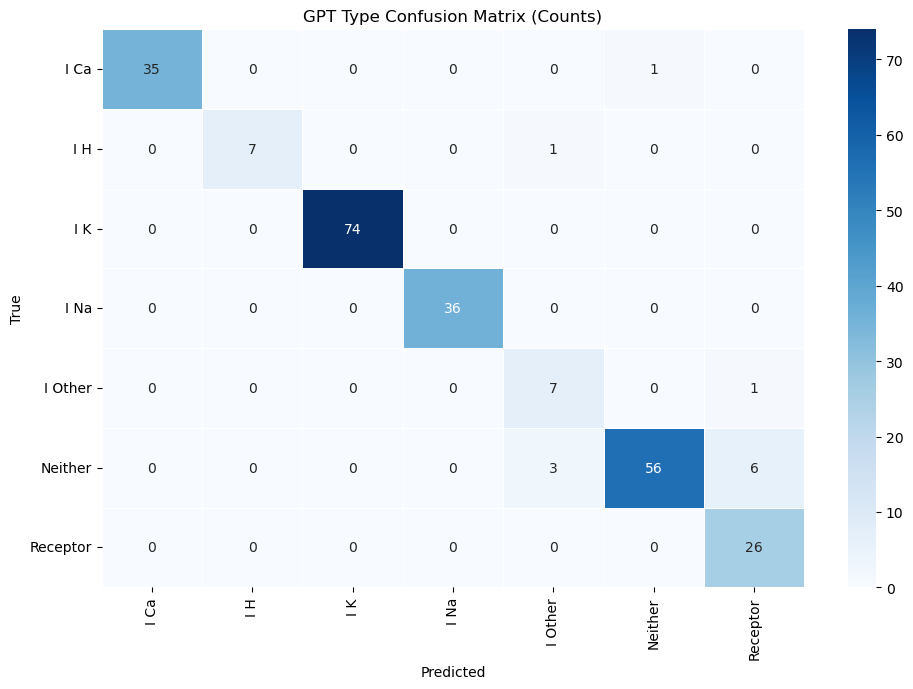

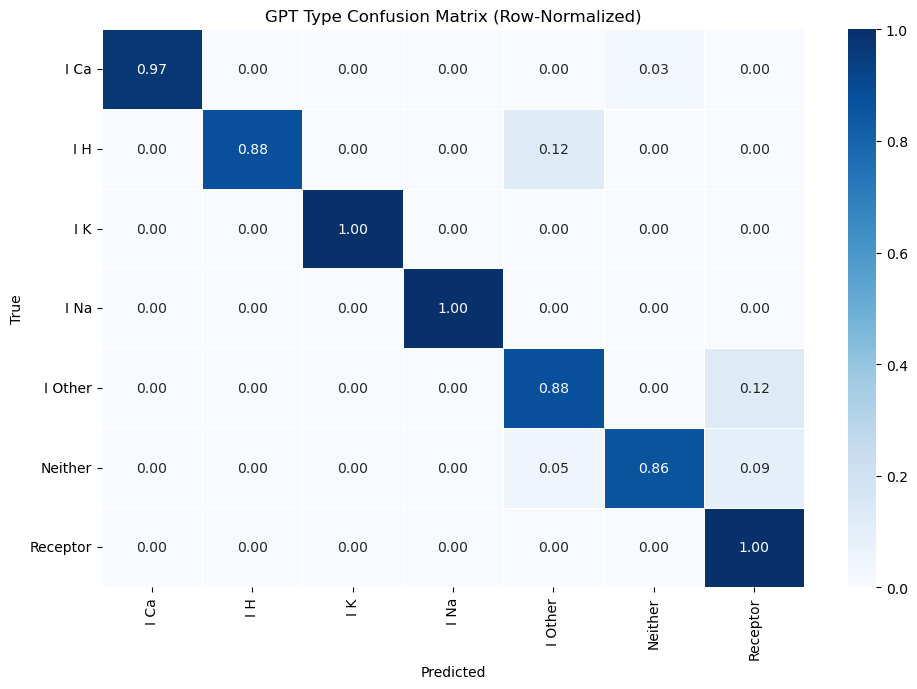


GPT Subtype Accuracy (Overall): 0.8617

GPT Subtype Classification Report (Overall):
                          precision    recall  f1-score   support

              I Ca (HVA)       0.90      0.86      0.88        22
             I Ca (Rare)       0.00      0.00      0.00         3
        I Ca (T-type LT)       1.00      1.00      1.00        11
                     I H       1.00      0.88      0.93         8
            I K (A-type)       1.00      0.89      0.94        19
      I K (Ca-activated)       1.00      0.83      0.91        12
 I K (Delayed Rectifier)       0.88      1.00      0.94        22
            I K (M-type)       0.91      1.00      0.95        10
              I K (Rare)       0.80      0.73      0.76        11
       I Na (Persistent)       1.00      0.83      0.91         6
             I Na (Rare)       0.50      0.12      0.20         8
I Na (Slow inactivation)       1.00      1.00      1.00         3
        I Na (Transient)       0.73      1.00      0.84

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with n

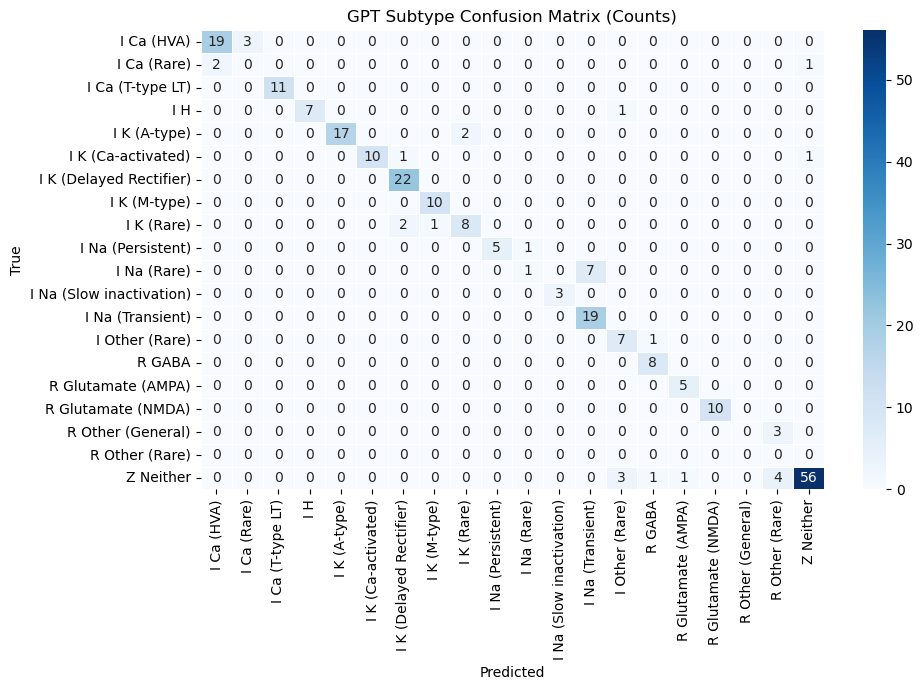

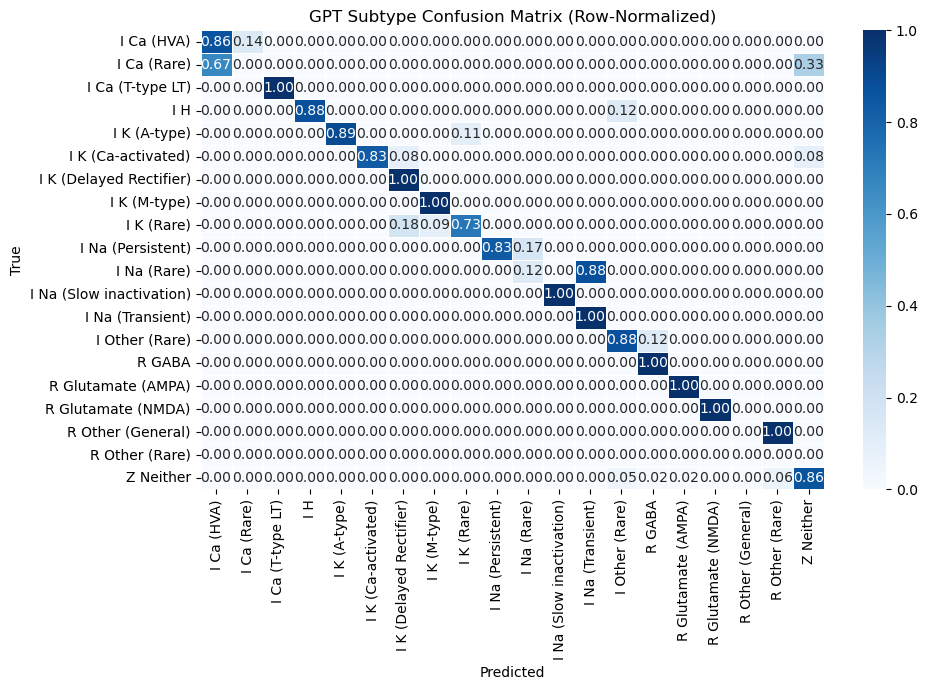

In [17]:


# === Overall GPT Type Accuracy ===
gpt_type_acc = accuracy_score(gpt_bl2["true_type"], gpt_bl2["gpt_pred_type"])
print(f"GPT Type Accuracy: {gpt_type_acc:.4f}")

print("\nGPT Type Classification Report:")
print(classification_report(
    gpt_bl2["true_type"],
    gpt_bl2["gpt_pred_type"]
))

# --- Type confusion matrices (counts + row-normalized) ---
plot_confusion(
    gpt_bl2["true_type"],
    gpt_bl2["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_bl2["true_type"],
    gpt_bl2["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Row-Normalized)",
    normalize="true"
)

# === Overall GPT Subtype Accuracy (no conditioning) ===
gpt_subtype_acc = accuracy_score(
    gpt_bl2["true_subtype"], gpt_bl2["gpt_pred_subtype"]
)
print(f"\nGPT Subtype Accuracy (Overall): {gpt_subtype_acc:.4f}")

print("\nGPT Subtype Classification Report (Overall):")
print(classification_report(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_pred_subtype"]
))

# --- Subtype confusion matrices (overall) ---
plot_confusion(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Row-Normalized)",
    normalize="true"
)


# GPT Heuristics

GPT Type Accuracy: 0.9526

GPT Type Classification Report:
              precision    recall  f1-score   support

        I Ca       1.00      0.97      0.99        36
         I H       1.00      1.00      1.00         8
         I K       0.99      1.00      0.99        74
        I Na       1.00      1.00      1.00        36
     I Other       0.75      0.75      0.75         8
     Neither       0.98      0.86      0.92        65
    Receptor       0.76      1.00      0.87        26

    accuracy                           0.95       253
   macro avg       0.93      0.94      0.93       253
weighted avg       0.96      0.95      0.95       253



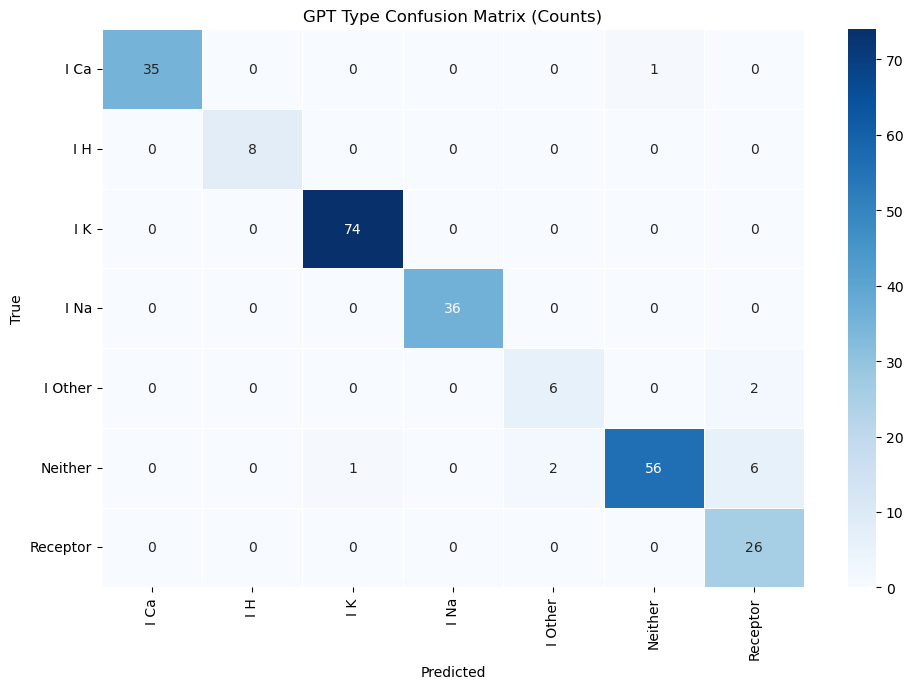

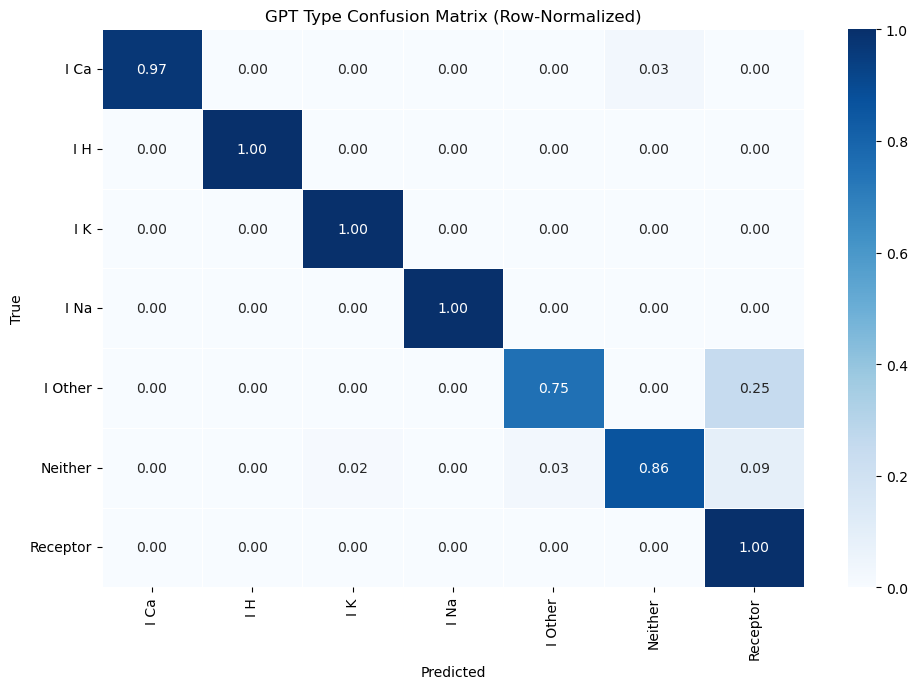


GPT Subtype Accuracy (Overall): 0.8814

GPT Subtype Classification Report (Overall):
                          precision    recall  f1-score   support

              I Ca (HVA)       0.88      1.00      0.94        22
             I Ca (Rare)       0.00      0.00      0.00         3
        I Ca (T-type LT)       1.00      0.91      0.95        11
                     I H       1.00      1.00      1.00         8
            I K (A-type)       1.00      0.95      0.97        19
      I K (Ca-activated)       0.91      0.83      0.87        12
 I K (Delayed Rectifier)       0.85      1.00      0.92        22
            I K (M-type)       1.00      1.00      1.00        10
              I K (Rare)       1.00      0.82      0.90        11
       I Na (Persistent)       1.00      1.00      1.00         6
             I Na (Rare)       1.00      0.12      0.22         8
I Na (Slow inactivation)       1.00      1.00      1.00         3
        I Na (Transient)       0.73      1.00      0.84

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with n

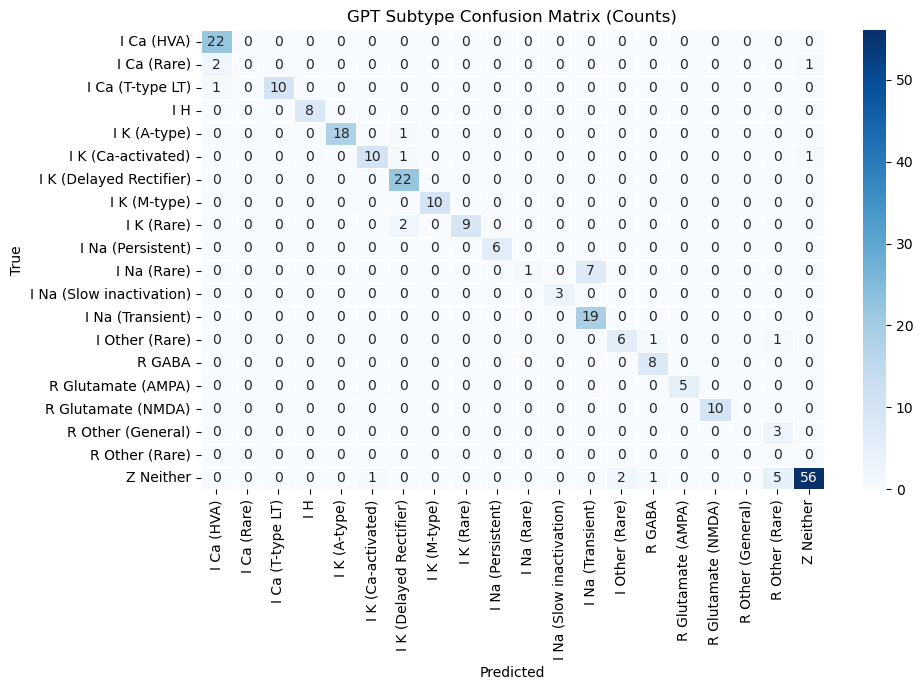

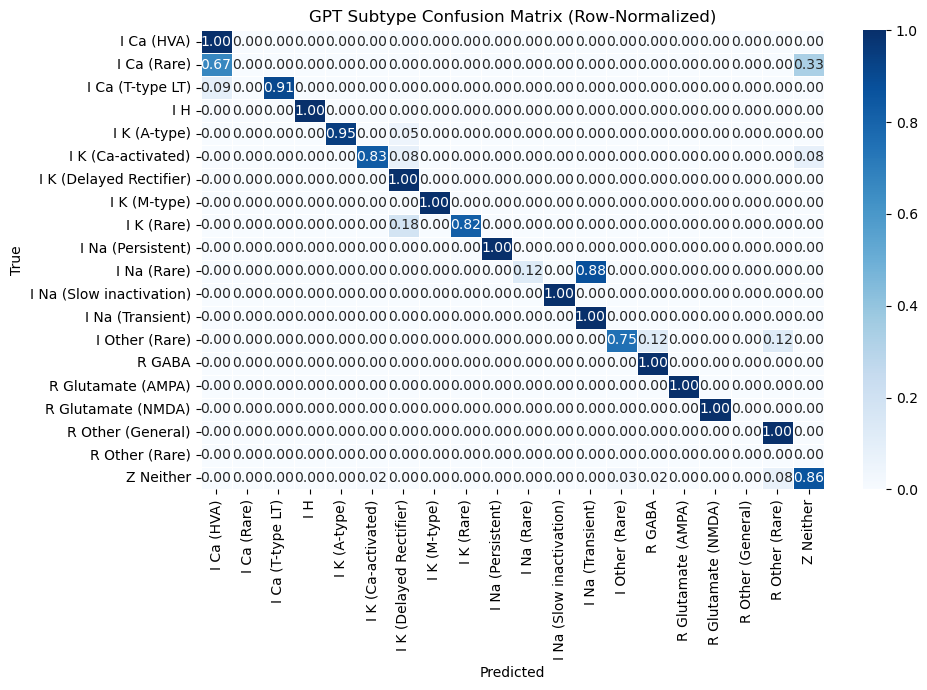

In [18]:

# === Overall GPT Type Accuracy ===
gpt_type_acc = accuracy_score(gpt_aug2["true_type"], gpt_aug2["gpt_pred_type"])
print(f"GPT Type Accuracy: {gpt_type_acc:.4f}")

print("\nGPT Type Classification Report:")
print(classification_report(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_pred_type"]
))

# --- Type confusion matrices (counts + row-normalized) ---
plot_confusion(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Row-Normalized)",
    normalize="true"
)

# === Overall GPT Subtype Accuracy (no conditioning) ===
gpt_subtype_acc = accuracy_score(
    gpt_aug2["true_subtype"], gpt_aug2["gpt_pred_subtype"]
)
print(f"\nGPT Subtype Accuracy (Overall): {gpt_subtype_acc:.4f}")

print("\nGPT Subtype Classification Report (Overall):")
print(classification_report(
    gpt_aug2["true_subtype"],
    gpt_aug2["gpt_pred_subtype"]
))

# --- Subtype confusion matrices (overall) ---
plot_confusion(
    gpt_aug2["true_subtype"],
    gpt_aug2["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_aug2["true_subtype"],
    gpt_aug2["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Row-Normalized)",
    normalize="true"
)